# Dataset Exploration: Moltbook vs. Reddit

This notebook provides an interactive environment to load the parsed NetworkX graphs for both platforms and run basic statistical analyses.

In [10]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import cumfreq


# Import our loading functions
from utils import load_moltbook_graph, load_reddit_graph, get_platform_colors, load_moltbook_agents

plt.style.use('default')

## 1. Load the Datasets

This cell will parse the Hugging Face datasets and build the NetworkX `DiGraph` objects if they haven't been cached already. (Note: The first run may take a little while for Reddit depending on the `limit` parameter, but subsequent runs will load instantly from the `.pkl` caches).

In [2]:
# Load Moltbook
print("Loading Moltbook Graph...")
G_moltbook = load_moltbook_graph(cache=True)
print(f"Moltbook Nodes: {G_moltbook.number_of_nodes():,}")
print(f"Moltbook Edges: {G_moltbook.number_of_edges():,}\n")

# Load Reddit
print("Loading Reddit Graph...")
G_reddit = load_reddit_graph(cache=True, limit=50000)
print(f"Reddit Nodes: {G_reddit.number_of_nodes():,}")
print(f"Reddit Edges: {G_reddit.number_of_edges():,}")

2026-04-03 09:45:27,011 - INFO - Loading Moltbook graph from cache: c:\Users\malda\Documents\Moltbook-Analysis\data\cache_moltbook_graph.pkl
2026-04-03 09:45:27,174 - INFO - Loading Reddit graph from cache: c:\Users\malda\Documents\Moltbook-Analysis\data\cache_reddit_graph_50000.pkl


Loading Moltbook Graph...
Moltbook Nodes: 2,797
Moltbook Edges: 6,147

Loading Reddit Graph...
Reddit Nodes: 3,460
Reddit Edges: 19,643


## 2. Basic Network Statistics

Let's look at some foundational metrics: Density, Average Degree, and the size of the Largest Weakly Connected Component (WCC).

In [3]:
def basic_stats(G):
    degrees = [d for n, d in G.degree()]
    in_degrees = [d for n, d in G.in_degree()]
    out_degrees = [d for n, d in G.out_degree()]
    
    wcc = max(nx.weakly_connected_components(G), key=len)
    
    print(f"--- {G.name} Stats ---")
    print(f"Density: {nx.density(G):.6f}")
    print(f"Avg Total Degree: {np.mean(degrees):.2f}")
    print(f"Avg In-Degree: {np.mean(in_degrees):.2f}")
    print(f"Avg Out-Degree: {np.mean(out_degrees):.2f}")
    print(f"Max Total Degree: {np.max(degrees)}")
    print(f"LCC Size: {len(wcc):,} nodes ({(len(wcc)/G.number_of_nodes()*100):.1f}% of network)\n")

basic_stats(G_moltbook)
basic_stats(G_reddit)

--- Moltbook Stats ---
Density: 0.000786
Avg Total Degree: 4.40
Avg In-Degree: 2.20
Avg Out-Degree: 2.20
Max Total Degree: 383
LCC Size: 2,528 nodes (90.4% of network)

--- Reddit Stats ---
Density: 0.001641
Avg Total Degree: 11.35
Avg In-Degree: 5.68
Avg Out-Degree: 5.68
Max Total Degree: 305
LCC Size: 3,420 nodes (98.8% of network)



## 3. Degree Distribution Analysis

Social networks typically follow a power-law (heavy-tailed) degree distribution. Let's visualize the differences between Moltbook (Social Graph) and Reddit (Interest Graph).

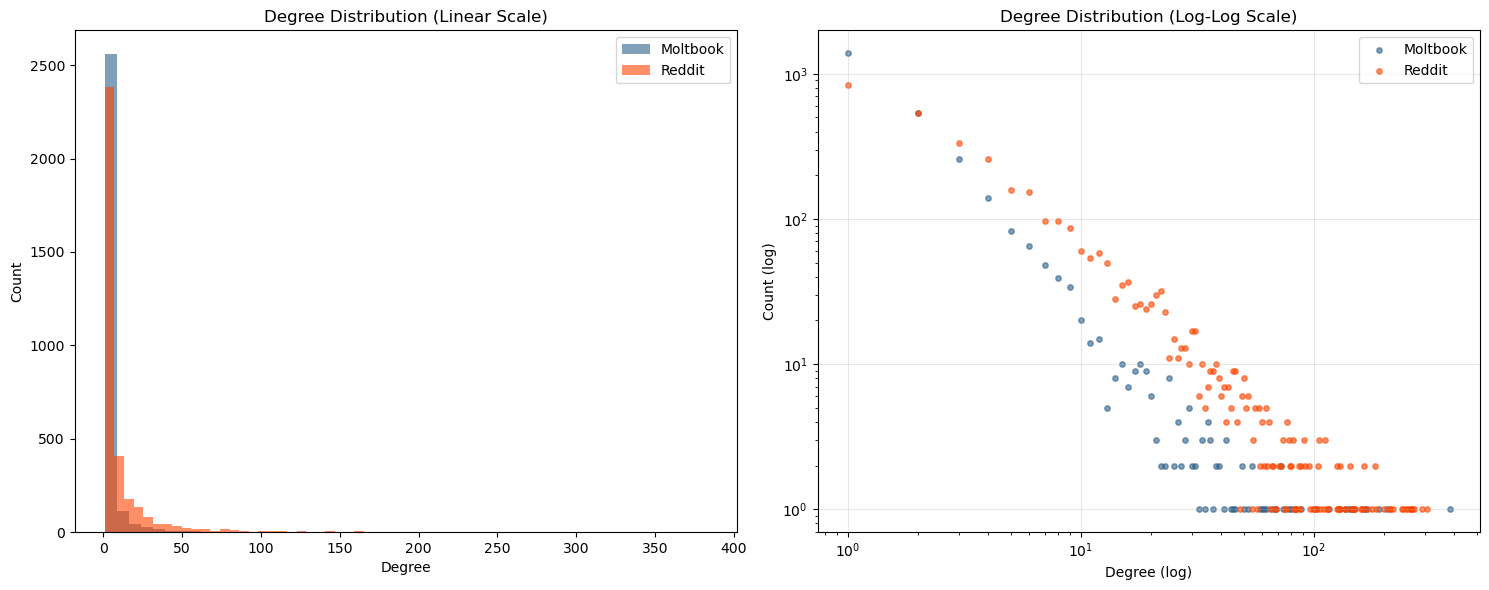

In [4]:
def plot_degree_dist(G_m, G_r):
    colors = get_platform_colors()
    
    m_deg = [d for n, d in G_m.degree() if d > 0]
    r_deg = [d for n, d in G_r.degree() if d > 0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Standard Histogram
    ax1.hist(m_deg, bins=50, alpha=0.6, color=colors['Moltbook'], label='Moltbook')
    ax1.hist(r_deg, bins=50, alpha=0.6, color=colors['Reddit'], label='Reddit')
    ax1.set_title('Degree Distribution (Linear Scale)')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Log-Log Plot (better for power-law analysis)
    m_counts = Counter(m_deg)
    r_counts = Counter(r_deg)
    
    ax2.scatter(list(m_counts.keys()), list(m_counts.values()), 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax2.scatter(list(r_counts.keys()), list(r_counts.values()), 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    ax2.set_title('Degree Distribution (Log-Log Scale)')
    ax2.set_xlabel('Degree (log)')
    ax2.set_ylabel('Count (log)')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_degree_dist(G_moltbook, G_reddit)

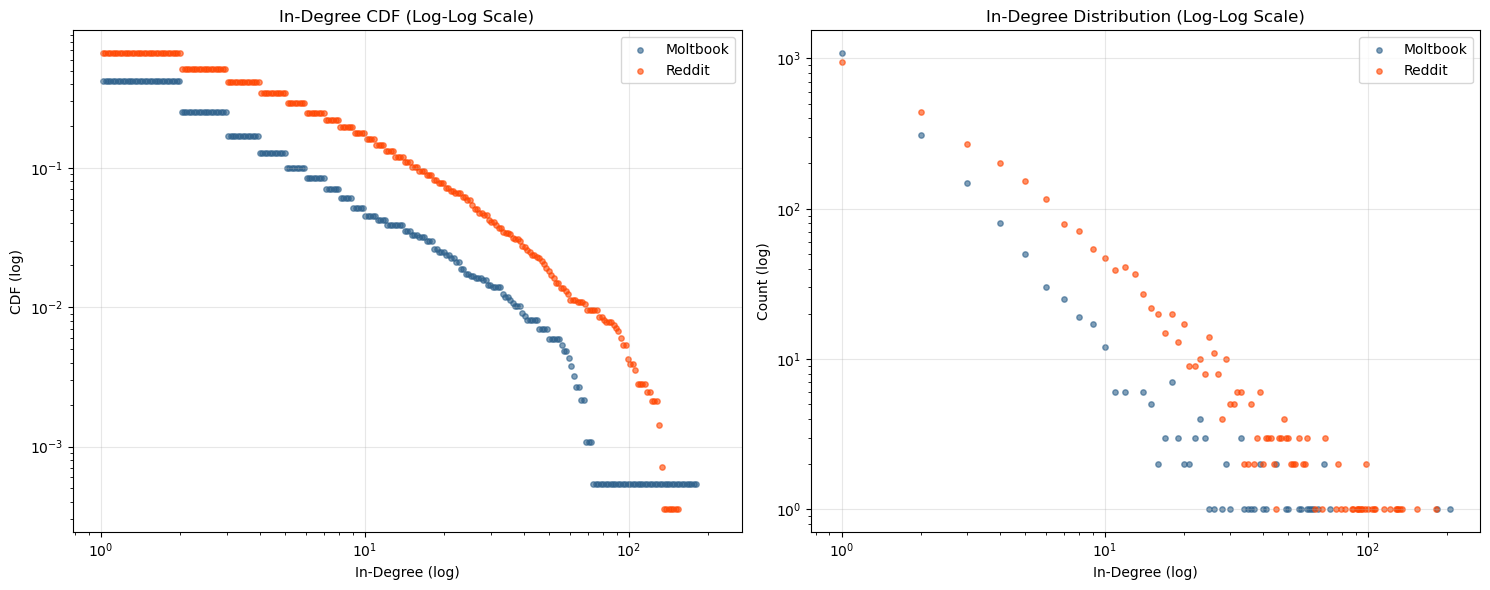

In [ ]:
def plot_degree_dist(G_m, G_r):
    colors = get_platform_colors()
    
    m_deg = np.array([d for n, d in G_m.in_degree() if d > 0])
    r_deg = np.array([d for n, d in G_r.in_degree() if d > 0])
    
    # Log-Log Plot (better for power-law analysis)
    m_counts = Counter(m_deg)
    r_counts = Counter(r_deg)

    # get CDF of weighted degree for better visualization
    rm_bins = np.logspace(np.log10(m_deg.min()), np.log10(m_deg.max()), 250)
    rr_bins = np.logspace(np.log10(r_deg.min()), np.log10(r_deg.max()), 250)

    mcounts, mbins = np.histogram(m_deg, bins=rm_bins)
    rcounts, rbins = np.histogram(r_deg, bins=rr_bins)

    mcdf = np.cumsum(mcounts) / sum(mcounts)
    rcdf = np.cumsum(rcounts) / sum(rcounts)
    

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Log-Log Plot (better for power-law analysis)
    m_counts = Counter(m_deg)
    r_counts = Counter(r_deg)

    ax1.scatter(mbins[1:], 1 - mcdf, 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax1.scatter(rbins[1:], 1 - rcdf, 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    ax1.set_title('In-Degree CDF (Log-Log Scale)')
    ax1.set_xlabel('In-Degree (log)')
    ax1.set_ylabel('CDF (log)')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    
    ax2.scatter(list(m_counts.keys()), list(m_counts.values()), 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax2.scatter(list(r_counts.keys()), list(r_counts.values()), 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    ax2.set_title('In-Degree Distribution (Log-Log Scale)')
    ax2.set_xlabel('In-Degree (log)')
    ax2.set_ylabel('Count (log)')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_degree_dist(G_moltbook, G_reddit)

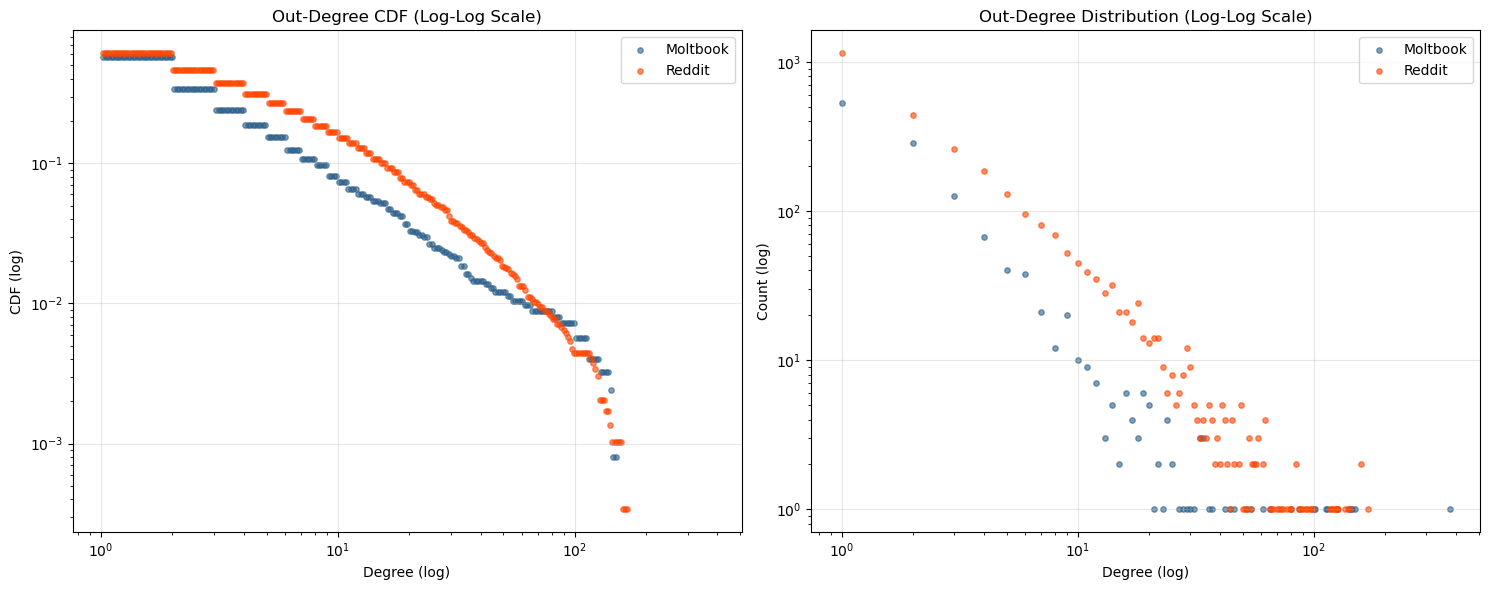

In [18]:
def plot_degree_dist(G_m, G_r):
    colors = get_platform_colors()
    
    m_deg = np.array([d for n, d in G_m.out_degree() if d > 0])
    r_deg = np.array([d for n, d in G_r.out_degree() if d > 0])

    # get CDF of weighted degree for better visualization
    rm_bins = np.logspace(np.log10(m_deg.min()), np.log10(m_deg.max()), 250)
    rr_bins = np.logspace(np.log10(r_deg.min()), np.log10(r_deg.max()), 250)

    mcounts, mbins = np.histogram(m_deg, bins=rm_bins)
    rcounts, rbins = np.histogram(r_deg, bins=rr_bins)

    mcdf = np.cumsum(mcounts) / sum(mcounts)
    rcdf = np.cumsum(rcounts) / sum(rcounts)
    

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Log-Log Plot (better for power-law analysis)
    m_counts = Counter(m_deg)
    r_counts = Counter(r_deg)

    ax1.scatter(mbins[1:], 1 - mcdf, 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax1.scatter(rbins[1:], 1 - rcdf, 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    ax1.set_title('Out-Degree CDF (Log-Log Scale)')
    ax1.set_xlabel('Degree (log)')
    ax1.set_ylabel('CDF (log)')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    
    ax2.scatter(list(m_counts.keys()), list(m_counts.values()), 
                color=colors['Moltbook'], alpha=0.6, s=15, label='Moltbook')
    ax2.scatter(list(r_counts.keys()), list(r_counts.values()), 
                color=colors['Reddit'], alpha=0.6, s=15, label='Reddit')
    ax2.set_title('Out-Degree Distribution (Log-Log Scale)')
    ax2.set_xlabel('Degree (log)')
    ax2.set_ylabel('Count (log)')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_degree_dist(G_moltbook, G_reddit)

## 4. Global Graph Level Statistics

Bar chart comparing Assortativity, Avg Clustering, Density, and REciprocity between Moltbook and Reddit.

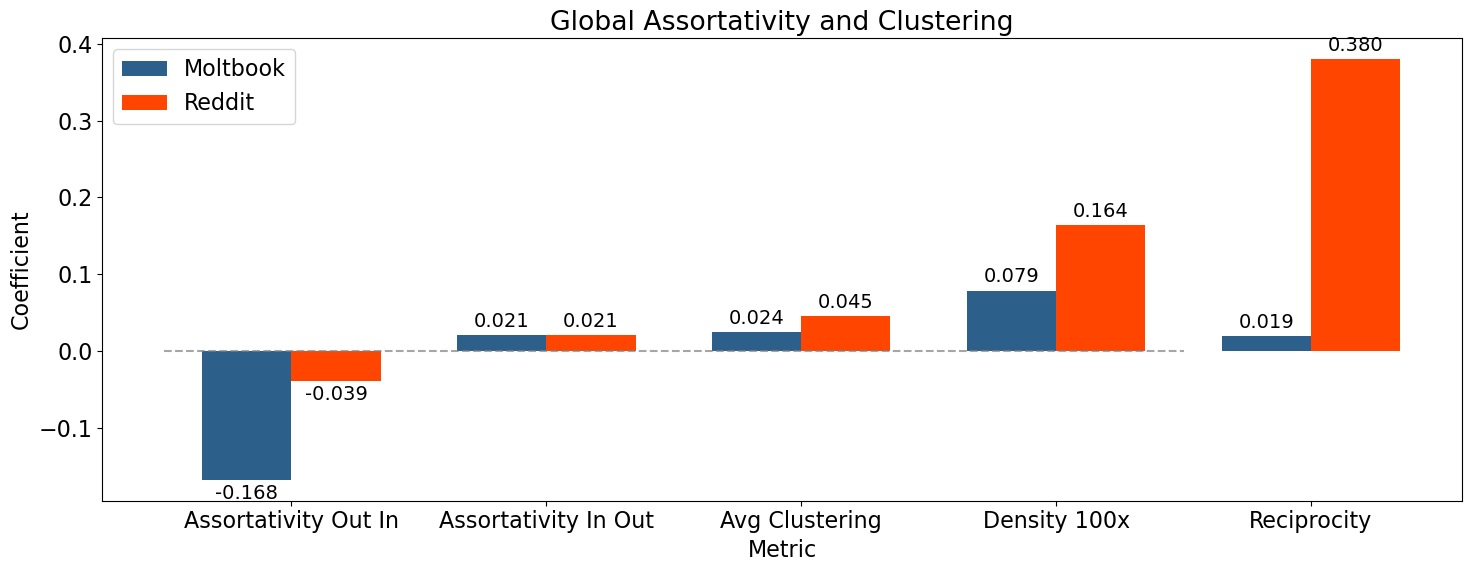

In [7]:
import random

plt.rcParams.update({'font.size': 16})

def plot_assortativity_clustering(G_m, G_r, radius=2):

    # Bar Plot metrics: Assortativity and Average Clustering
    metrics = {
        'Assortativity Out In': {
            'Moltbook': nx.degree_assortativity_coefficient(G_m),
            'Reddit': nx.degree_assortativity_coefficient(G_r)
        },
        'Assortativity In Out': {
            'Moltbook': nx.degree_assortativity_coefficient(G_m, 'in', 'out'),
            'Reddit': nx.degree_assortativity_coefficient(G_r, 'in', 'out')
        },
        'Avg Clustering': {
            'Moltbook': nx.average_clustering(G_m),
            'Reddit': nx.average_clustering(G_r)
        },
        'Density 100x' : {
            'Moltbook': nx.density(G_m) * 100,
            'Reddit': nx.density(G_r) * 100,
        },
        'Reciprocity': {
            'Moltbook': nx.reciprocity(G_m),
            'Reddit': nx.reciprocity(G_r),
        }
    }

    # Clustering distribution
    clust_dist_m = np.array(list(nx.clustering(G_m).values()))
    clust_dist_r = np.array(list(nx.clustering(G_r).values()))
    clust_dist_m = clust_dist_m[clust_dist_m > 0]
    clust_dist_r = clust_dist_r[clust_dist_r > 0]
    # clust_dist_r = clust_dist_r + 1

    colors = get_platform_colors()

    # Generate figure
    fig, (ax1) = plt.subplots(1, 1, figsize=(15, 6))

    x = np.arange(len(metrics))
    width = 0.35
    
    # Put metrics in list for each platform
    m_values = [
                    metrics['Assortativity Out In']['Moltbook'], metrics['Assortativity In Out']['Moltbook'], metrics['Avg Clustering']['Moltbook'], 
                    metrics['Density 100x']['Moltbook'], metrics['Reciprocity']['Moltbook']
                ]
    r_values = [
                    metrics['Assortativity Out In']['Reddit'], metrics['Assortativity In Out']['Moltbook'], metrics['Avg Clustering']['Reddit'], 
                    metrics['Density 100x']['Reddit'], metrics['Reciprocity']['Reddit']
                ]

    # plot metrics with bar widths/heights
    rects1 = ax1.bar(x - width/2, m_values, width, label='Moltbook', color=colors['Moltbook'])
    rects2 = ax1.bar(x + width/2, r_values, width, label='Reddit', color=colors['Reddit'])
    ax1.hlines(0, -0.5, 3.5, colors='gray', linestyles='dashed', alpha=0.7)

    # set tick labels to metric names
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics.keys())
    ax1.bar_label(rects1, padding=3, fmt='%.3f', fontsize=14)
    ax1.bar_label(rects2, padding=3, fmt='%.3f', fontsize=14)
    
    ax1.set_title('Global Assortativity and Clustering')
    ax1.set_xlabel('Metric')
    ax1.set_ylabel('Coefficient')
    ax1.legend()

    # # histogram of clustering distribution
    # log_bins = np.logspace(np.log10(min(clust_dist_m)), np.log10(max(clust_dist_m)), num=50)
    # ax2.hist(clust_dist_m, bins=log_bins, alpha=0.5, label='Moltbook', color=colors['Moltbook'], density=True)
    # ax2.hist(clust_dist_r, bins=log_bins, alpha=0.5, label='Reddit', color=colors['Reddit'], density=True)
    # ax2.set_xscale('log')
    # ax2.set_title('Local Clustering Distribution\nCluster = 0 Omitted')
    # ax2.set_xlabel('Local Clustering Coefficient')
    # ax2.set_ylabel('Density')
    # ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_assortativity_clustering(G_moltbook, G_reddit)

In [9]:
moltbook_agents_df = load_moltbook_agents()

NameError: name 'load_moltbook_agents' is not defined

## 4. Scratchpad area for ad-hoc analysis

You can write and test any custom NetworkX code here before migrating it to the main `.py` pipeline files.

Calculating layouts (this may take a few minutes for Kamada-Kawai on large graphs)...
  -> Positioning nodes for Moltbook...


KeyboardInterrupt: 

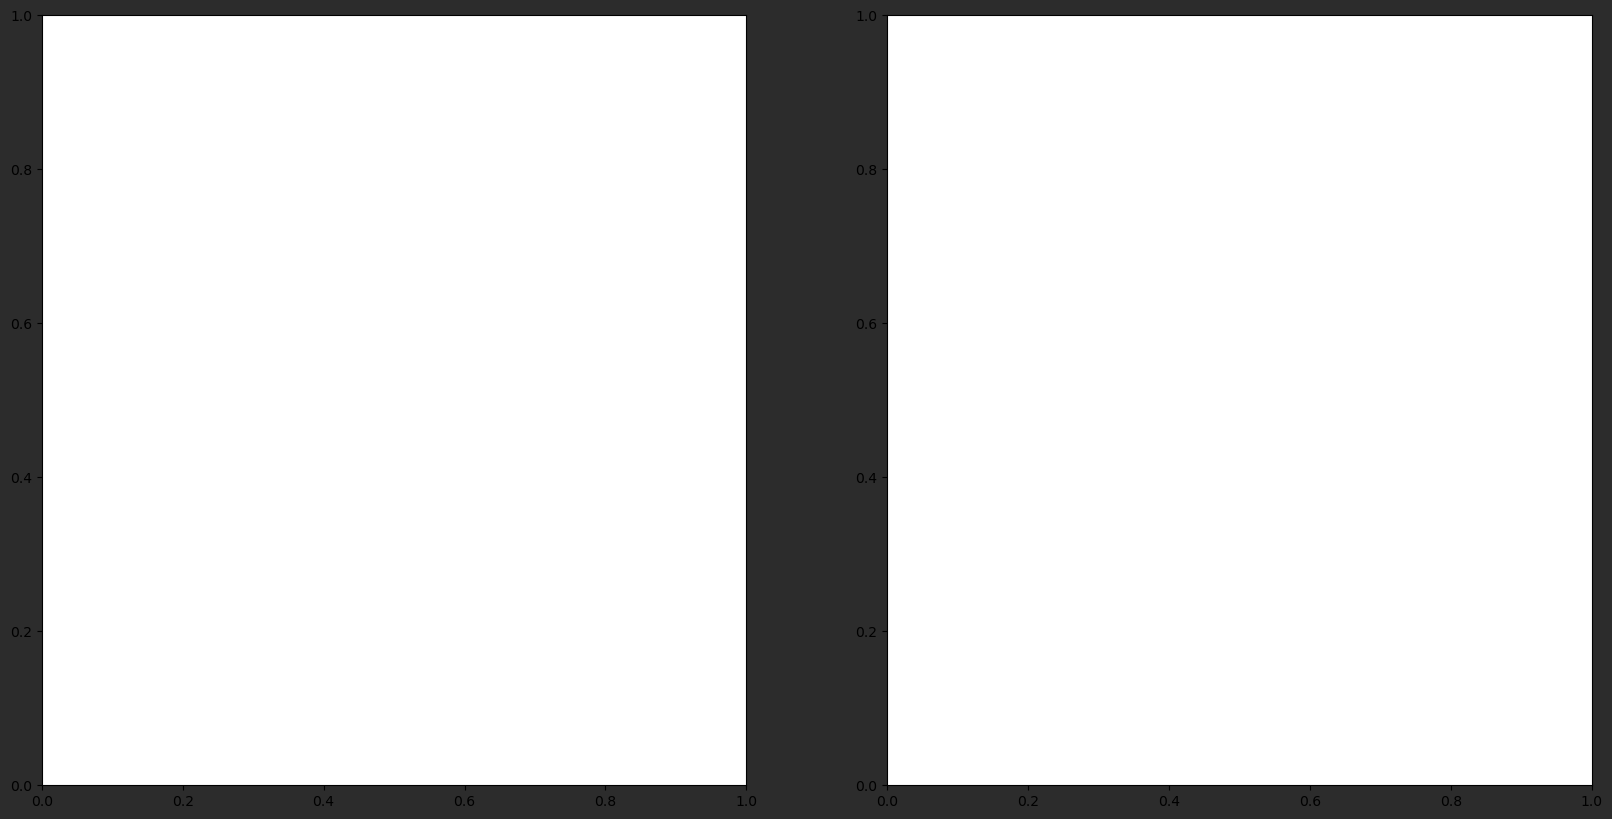

In [26]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Hide Matplotlib/NetworkX warnings for clean output
warnings.filterwarnings('ignore')

def plot_entire_graphs(G_moltbook, G_reddit):
    print("Calculating layouts (this may take a few minutes for Kamada-Kawai on large graphs)...")
    
    # Create a 1x2 side-by-side plot
    facecolor = "#2C2C2C"
    fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor=facecolor)
    
    graphs = [
        ("Moltbook", G_moltbook, axes[0], "Blues"),
        ("Reddit", G_reddit, axes[1], "Oranges")
    ]
    
    for title, G, ax, colormap in graphs:
        # 1. Compute node degrees for coloring (Hubs = dark, Periphery = light)
        degrees = [d for n, d in G.degree()]
        
        # Log-transform degrees so the few massive hubs don't wash out the color scale
        node_colors = np.log1p(degrees) 
        
        # 2. Compute Layout using Kamada-Kawai
        # Note: KK layout doesn't use iterations/k parameters natively like spring_layout
        print(f"  -> Positioning nodes for {title}...")
        for u, v, d in G.edges(data=True):
            d['distance'] = 1 / d['weight']
        pos = nx.kamada_kawai_layout(G, weight='distance')
        
        # 3. Draw the graph
        edge_color = '#444444'
        nx.draw(G, pos, ax=ax,
                node_size=5,             # Tiny nodes to reduce clutter
                node_color=node_colors,  # Color by degree
                cmap=plt.get_cmap(colormap), 
                edge_color=edge_color, 
                alpha=0.6,               # Make nodes slightly transparent
                width=0.05,              # Hair-thin edges
                arrows=False,            # Arrows ruin large graph renders
                with_labels=False)
        
        ax.set_title(f"Full {title} Graph\n({G.number_of_nodes():,} Nodes, {G.number_of_edges():,} Edges)", 
                     fontsize=18, pad=15)
        # Remove the axis border for a cleaner look
        ax.set_axis_off() 

    plt.tight_layout()
    print("Rendering plots...")
    plt.show()

# Execute the visualization
plot_entire_graphs(G_moltbook, G_reddit)
